# **IMDB Movie Review Sentiment Classification with Simple RNN (TF/Keras)**

**Goal:** Build a simple RNN that classifies a raw text movie review as *positive* or *negative*.

**Dataset:** IMDB 50K Movie Reviews — raw text reviews with sentiment labels.

**Kaggle Link:** [IMDB Dataset of 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

**Steps:**
Load raw text → Explore → Split → Vectorize text → Build RNN → Train & validate → Evaluate → Save & reload model → Predict on new reviews

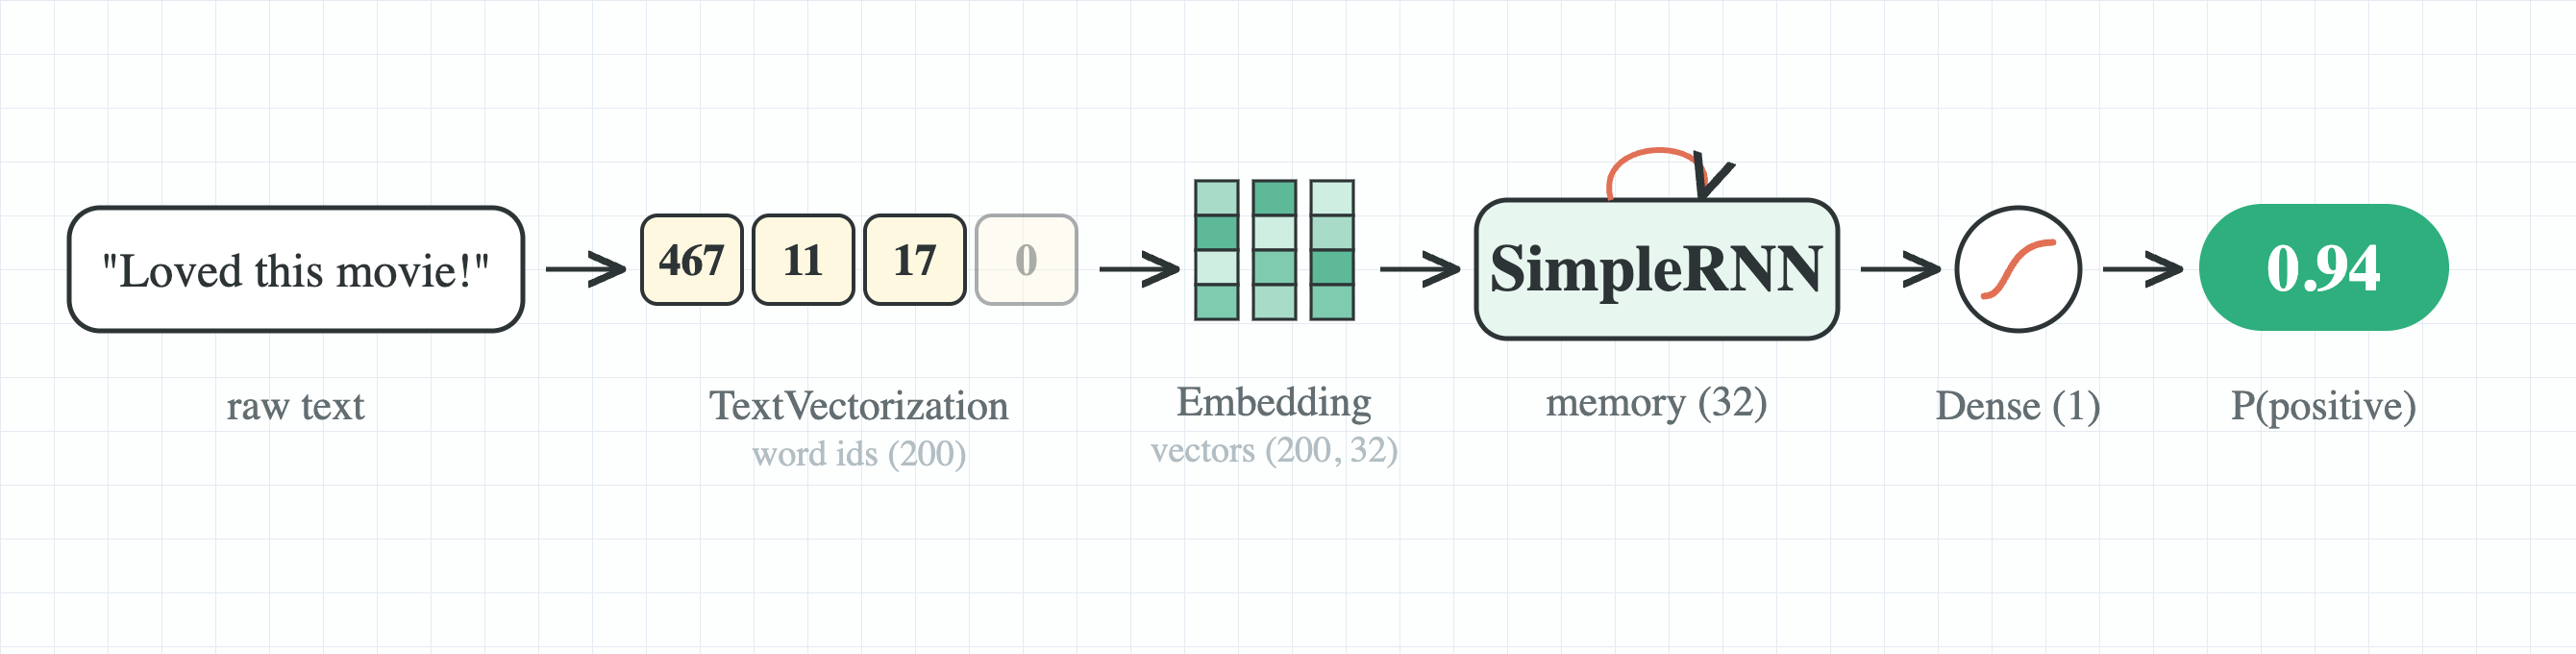

## **1. Imports & Setup**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import kagglehub
!pip install tensorflow
import tensorflow as tf
from tensorflow import keras

from sklearn.model_selection import train_test_split

from sklearn.metrics import confusion_matrix

print("Tensorflow version:", tf.__version__)

Tensorflow version: 2.21.0


In [ ]:
# seeding for reproducibility
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

## **2. Load the data**

In [ ]:
# downlaod the dataset
dataset_path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
print(dataset_path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
/kaggle/input/imdb-dataset-of-50k-movie-reviews


In [ ]:
# !ls "/kaggle/input/imdb-dataset-of-50k-movie-reviews"

In [ ]:
print(f"{dataset_path}/IMDB Dataset.csv")

/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [ ]:
# load the data from csv file to a pandas df
df = pd.read_csv(f"{dataset_path}/IMDB Dataset.csv")

## **3. Quick Exploration**

In [ ]:
df.shape

(50000, 2)

In [ ]:
# look at one raw full review
print(df["review"][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [ ]:
# reviews contain html line break tags - remove them so that they dont become junk tokens
df["review"] = df["review"].str.replace("<br />", " ", regex=False)

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. The filming t...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
# check the target distribution
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
# downsample to 20k reviews
df = df.groupby("sentiment").sample(n=10000, random_state=SEED).reset_index(drop=True)

df["sentiment"].value_counts()

,count
sentiment,
negative,10000
positive,10000


In [ ]:
df.shape

(20000, 2)

In [ ]:
df.head()

,review,sentiment
0,I was looking forward to seeing Bruce Willis i...,negative
1,Bugs Bunny accidentally ends up at the South P...,negative
2,I find it difficult to comprehend what makes v...,negative
3,It's been said several times - not least by me...,negative
4,New rule. Nobody is allowed to make any more Z...,negative


In [ ]:
# review length in words
df["review"].str.split().str.len().describe()

,review
count,20000.000000
mean,228.177750
std,168.748685
min,4.000000
25%,125.000000
50%,171.000000
75%,277.250000
max,2459.000000


In [ ]:
# convert labels to 0 and 1
df["sentiment"] = df["sentiment"].map({"negative": 0, "positive": 1}).astype(int)

In [ ]:
class_names = ["negative", "positive"]

In [ ]:
df.head()

,review,sentiment
0,I was looking forward to seeing Bruce Willis i...,0
1,Bugs Bunny accidentally ends up at the South P...,0
2,I find it difficult to comprehend what makes v...,0
3,It's been said several times - not least by me...,0
4,New rule. Nobody is allowed to make any more Z...,0


## **4. Train/Val/Test Split**

In [ ]:
# features (X) = the raw text, target (y) = the label
X = df["review"].values
y = df["sentiment"].values

In [ ]:
# first peel off the test set (20%)
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

# then split the rest into train (70%) and validation (10%)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.125, stratify=y_train_full, random_state=SEED
)

print("Train:", X_train.shape)
print("Val:  ", X_val.shape)
print("Test: ", X_test.shape)

Train: (14000,)
Val:   (2000,)
Test:  (4000,)


In [ ]:
# X_train[0]

## **5. Text Vectorization (raw text → numbers)**

Neural networks can't read text — the `TextVectorization` layer converts each review to a sequence of integers in 3 steps:
- **standardize** — lowercase + strip punctuation
- **tokenize** — split into words
- **map** — each word → an integer id from a learned vocabulary (and pad/cut to a fixed length)

In [ ]:
# keep the 10,000 MOST FREQUENT WORDS; use only the first 200 words in each review
VOCAB_SIZE = 10000
MAX_LEN = 200

vectorize_layer = keras.layers.TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_sequence_length=MAX_LEN
)

>Note: The vocabulary is learned from train data only — building it on val/test would leak their words into training (same idea as fitting the scaler on train only).

In [ ]:
# adapt = build the vocabulary from the training reviews
vectorize_layer.adapt(X_train)

In [ ]:
# inspect the learned vocabulary
vocab = vectorize_layer.get_vocabulary()

print("Vocabulary size:", len(vocab))
print("First 20 words:", vocab[:20])
# index 0 = padding, index 1 = [UNK] (words not in vocabulary)

Vocabulary size: 10000
First 20 words: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('a'), np.str_('of'), np.str_('to'), np.str_('is'), np.str_('in'), np.str_('it'), np.str_('i'), np.str_('this'), np.str_('that'), np.str_('was'), np.str_('as'), np.str_('with'), np.str_('for'), np.str_('movie'), np.str_('but'), np.str_('film')]


In [ ]:
# see what this layer does to a sentence
sample = vectorize_layer(["this movie was great, great acting!"])
print(sample[0][:10].numpy())

[ 11  17  13  77  77 110   0   0   0   0]


## **6. Build a Simple RNN**

The model takes a raw text string and has 4 layers:
- **TextVectorization** — raw text → sequence of 200 word ids (the layer we just adapted)
- **Embedding** — each word id → a dense vector of 32 numbers (learned during training)
- **SimpleRNN** — reads the review word by word, keeping a running "memory" of what it has seen
- **Dense (sigmoid)** — outputs one probability: *how positive is this review?*

In [ ]:
model = keras.Sequential([

    # input: one raw text string
    keras.Input(shape=(1,), dtype=tf.string),

    # raw text -> sequence of word ids -> (200,)
    vectorize_layer,

    # embedding layer: each word id -> 32-dim vector: (200,) -> (200, 32)
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32, mask_zero=True),

    # RNN cell
    keras.layers.SimpleRNN(units=32),

    # 1 probability output
    keras.layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

### **Improved RNN Model (with Regularization & Dropout)**

In [ ]:
model = keras.Sequential([
    # input: one raw text string
    keras.Input(shape=(1,), dtype=tf.string),

    # raw text -> sequence of word ids -> (200,)
    vectorize_layer,

    # embedding layer: each word id -> 32-dim vector: (200,) -> (200, 32)
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=32, mask_zero=True),

    # Spatial Dropout to drop entire 1D feature maps instead of individual elements
    keras.layers.SpatialDropout1D(0.2, seed=SEED),

    # RNN cell with dropout and recurrent dropout
    keras.layers.SimpleRNN(units=32, dropout=0.2, recurrent_dropout=0.2, seed=SEED),

    # Dense output layer with L2 regularization to keep weights small
    keras.layers.Dense(1, activation="sigmoid", kernel_regularizer=keras.regularizers.l2(0.001))
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_5 (Embedding)         │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 200, 32)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

## **7. Model Compilation**

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### **Recompiling with customized Adam learning rate**

In [ ]:
# Using a slightly lower learning rate for Adam to stabilize training and mitigate overfitting
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## **8. Training the RNN**

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - accuracy: 0.5065 - loss: 0.7161 - val_accuracy: 0.5165 - val_loss: 0.6954
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5094 - loss: 0.7091 - val_accuracy: 0.5200 - val_loss: 0.6943
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5182 - loss: 0.7013 - val_accuracy: 0.5200 - val_loss: 0.6933
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 46ms/step - accuracy: 0.5171 - loss: 0.6990 - val_accuracy: 0.5380 - val_loss: 0.6923
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5301 - loss: 0.6936 - val_accuracy: 0.5245 - val_loss: 0.6915
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5269 - loss: 0.6938 - val_accuracy: 0.5350 - val_loss: 0.6913
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5280 - loss: 0.6921 - val_accuracy: 0.5295 - val_loss: 0.6907
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5356 - loss: 0.6886 - val_accu

### **Retraining the Regularized RNN**

In [ ]:
# We can increase the maximum epochs to 15, letting EarlyStopping restore the best weights
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=5, restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5586 - loss: 0.6832 - val_accuracy: 0.5435 - val_loss: 0.6883
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - accuracy: 0.5606 - loss: 0.6807 - val_accuracy: 0.5410 - val_loss: 0.6873
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5712 - loss: 0.6781 - val_accuracy: 0.5460 - val_loss: 0.6869
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - accuracy: 0.5823 - loss: 0.6734 - val_accuracy: 0.5400 - val_loss: 0.6855
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5860 - loss: 0.6725 - val_accuracy: 0.5570 - val_loss: 0.6837
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.5926 - loss: 0.6679 - val_accuracy: 0.5430 - val_loss: 0.6824
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6024 - loss: 0.6630 - val_accuracy: 0.5430 - val_loss: 0.6820
Epoch 8/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.6216 - loss: 0.6575 - val_accu

### **Upgrading to a Bidirectional LSTM Model to Improve Accuracy & Prevent Overfitting**

In [ ]:
# Re-building a powerful Bidirectional LSTM model with strong regularization
model = keras.Sequential([
    # Input raw text string
    keras.Input(shape=(1,), dtype=tf.string),

    # Vectorization layer
    vectorize_layer,

    # Embedding layer with masking support enabled
    keras.layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, mask_zero=True),

    # Dropout on embedding outputs
    keras.layers.SpatialDropout1D(0.3, seed=SEED),

    # Bidirectional LSTM captures complex long-range dependencies efficiently
    keras.layers.Bidirectional(keras.layers.LSTM(units=64, dropout=0.3, recurrent_dropout=0.3, seed=SEED)),

    # Dense output with L2 regularization to control overfitting
    keras.layers.Dense(1, activation="sigmoid", kernel_regularizer=keras.regularizers.l2(0.001))
])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_2            │ (None, 200)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_6 (Embedding)         │ (None, 200, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ (None, 200, 64)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 706,177 (2.69 MB)

 Trainable params: 706,177 (2.69 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model using the Adam optimizer with an optimal learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Use early stopping to monitor validation loss and prevent overfitting
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

# Train the upgraded Bidirectional LSTM model
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop]
)

Epoch 1/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 41s 336ms/step - accuracy: 0.6639 - loss: 0.6163 - val_accuracy: 0.7720 - val_loss: 0.4851
Epoch 2/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 331ms/step - accuracy: 0.7969 - loss: 0.4642 - val_accuracy: 0.7815 - val_loss: 0.5199
Epoch 3/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 329ms/step - accuracy: 0.8312 - loss: 0.4016 - val_accuracy: 0.8150 - val_loss: 0.4331
Epoch 4/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 330ms/step - accuracy: 0.8566 - loss: 0.3623 - val_accuracy: 0.7860 - val_loss: 0.4513
Epoch 5/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 332ms/step - accuracy: 0.8391 - loss: 0.3746 - val_accuracy: 0.8160 - val_loss: 0.4339
Epoch 6/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 331ms/step - accuracy: 0.8792 - loss: 0.3083 - val_accuracy: 0.8415 - val_loss: 0.3825
Epoch 7/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 330ms/step - accuracy: 0.8969 - loss: 0.2737 - val_accuracy: 0.8395 - val_loss: 0.3847
Epoch 8/15
110/110 ━━━━━━━━━━━━━━━━━━━━ 36s 330ms/step - accuracy: 0.9048 - loss: 0

## **9. Learning Curves**

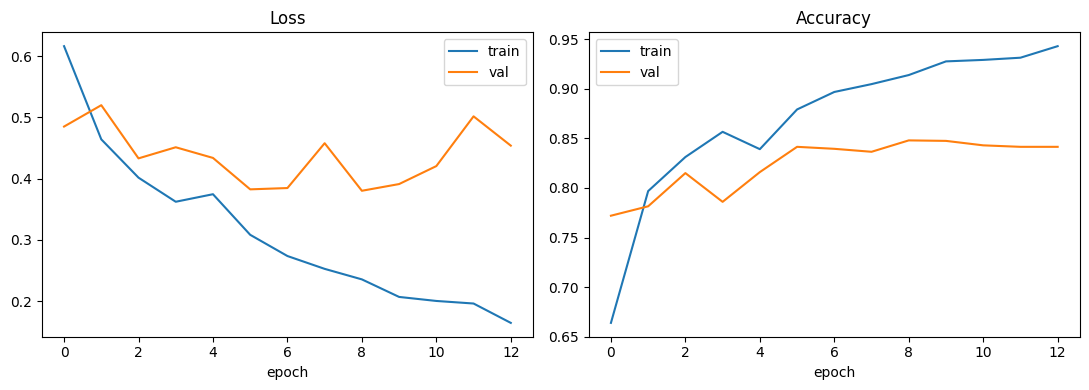

In [ ]:
hist = history.history

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.plot(hist["loss"], label="train")
plt.plot(hist["val_loss"], label="val")
plt.title("Loss"); plt.xlabel("epoch"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(hist["accuracy"], label="train")
plt.plot(hist["val_accuracy"], label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend()

plt.tight_layout()
plt.show()

## **10. Evaluation on Test data**

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print("Test loss:", round(test_loss, 3))
print("Test accuracy:", round(test_accuracy, 3))

Test loss: 0.361
Test accuracy: 0.858


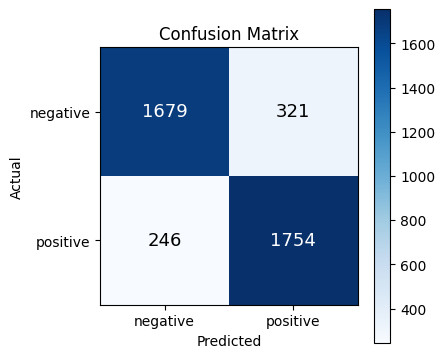

In [ ]:
y_prob = model.predict(X_test, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

# midpoint between the lightest and darkest cell - matches how imshow assigns colors
threshold = (cm.max() + cm.min()) / 2

plt.figure(figsize=(4.5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.xticks([0, 1], class_names)
plt.yticks([0, 1], class_names)
for i in range(2):
    for j in range(2):
        color = "white" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=13, color=color)
plt.colorbar()
plt.tight_layout()
plt.show()

## **11. Save the model**

>Note: The `TextVectorization` layer (with its vocabulary) is saved inside the model — no separate tokenizer file needed.

In [ ]:
model.save("imdb_sentiment_rnn.keras")

## **12. Reload the model and get prediction**

In [ ]:
# load the keras model back
loaded_model = keras.models.load_model("imdb_sentiment_rnn.keras")

In [ ]:
def predict_sentiment(review_text, model):
    """Predict the sentiment of a raw text review and print it"""

    # the model handles vectorization itself - just pass the raw string
    prob = model.predict(tf.constant([review_text]), verbose=0)[0][0]
    label = "POSITIVE" if prob >= 0.5 else "NEGATIVE"

    print(f"{label} ({prob:.3f}) - {review_text}")

In [ ]:
predict_sentiment("this movie was absolutely wonderful with brilliant acting and a great story", loaded_model)

POSITIVE (0.984) - this movie was absolutely wonderful with brilliant acting and a great story


In [ ]:
predict_sentiment("a boring waste of time with terrible acting and an awful plot", loaded_model)

NEGATIVE (0.001) - a boring waste of time with terrible acting and an awful plot


## **Wrap-up**

We built a simple RNN that classifies raw text IMDB movie reviews with ~85% test accuracy.

**What we did:** loaded raw text reviews → split → learned a vocabulary with `TextVectorization` (train only) → built TextVectorization → Embedding → SimpleRNN → Dense(sigmoid) → trained with early stopping → evaluated with a confusion matrix → saved/reloaded the model → wrapped it in a reusable `predict_sentiment()` function.

**Up next:** the same use case with an **LSTM** — a smarter RNN cell that remembers long-range context — and then **BERT**. Same pipeline, better models.